# VQ Learnable Query — 하이퍼파라미터 분석 리포트
학습 방법: k=32 projected-VQ global query, teacher-forced codec reconstruction (ce0 + 0.3·sub), n=400 LibriTTS-P.
평가: 공식 `EvaluationPipeline` method2 (Gen-Gen COS, WER). 기준 config = **lr 0.02 · cosine · warmup 0 · 300 steps**.

분석 축: **① step 수 ② learning rate ③ warmup 유무 ④ LR 스케줄러**.
주의: 이 학습은 시드 변동이 큼 → 가능한 한 다중 시드 평균±범위로 본다.

In [1]:
import json, csv, math
from pathlib import Path
import numpy as np, matplotlib.pyplot as plt, matplotlib as mpl
mpl.rcParams["figure.dpi"]=120; mpl.rcParams["font.size"]=10
ANA=Path("results/analysis"); ANA.mkdir(parents=True, exist_ok=True)
def summ(tag):
    f=Path(f"results/_summary/{tag}.json")
    if not f.exists(): return None
    m=json.load(open(f))["metrics"]; return m["sim_mean"], m["wer_mean"]
# baseline (lr0.02 cosine 300step) per seed from SWEEP_RESULTS.csv
BASE={}
for r in csv.DictReader(open("results/SWEEP_RESULTS.csv")):
    if r["recipe"]=="proj+cosine" and r["step"]=="300":
        BASE[r["seed"]]=(float(r["cos"]), float(r["wer"]))
print("baseline lr0.02/cosine/300 seeds:", {k:(round(v[0],3),round(v[1],3)) for k,v in BASE.items()})

baseline lr0.02/cosine/300 seeds: {'1': (0.421, 0.13), '2': (0.426, 0.155), '3': (0.373, 0.139), '4': (0.356, 0.217)}


## ① Step 수 — 더 오래 학습하면?
기존 proj+cosine 스텝 커브(seed 1–4 × step 100–600, lr0.02 cosine)를 재사용.

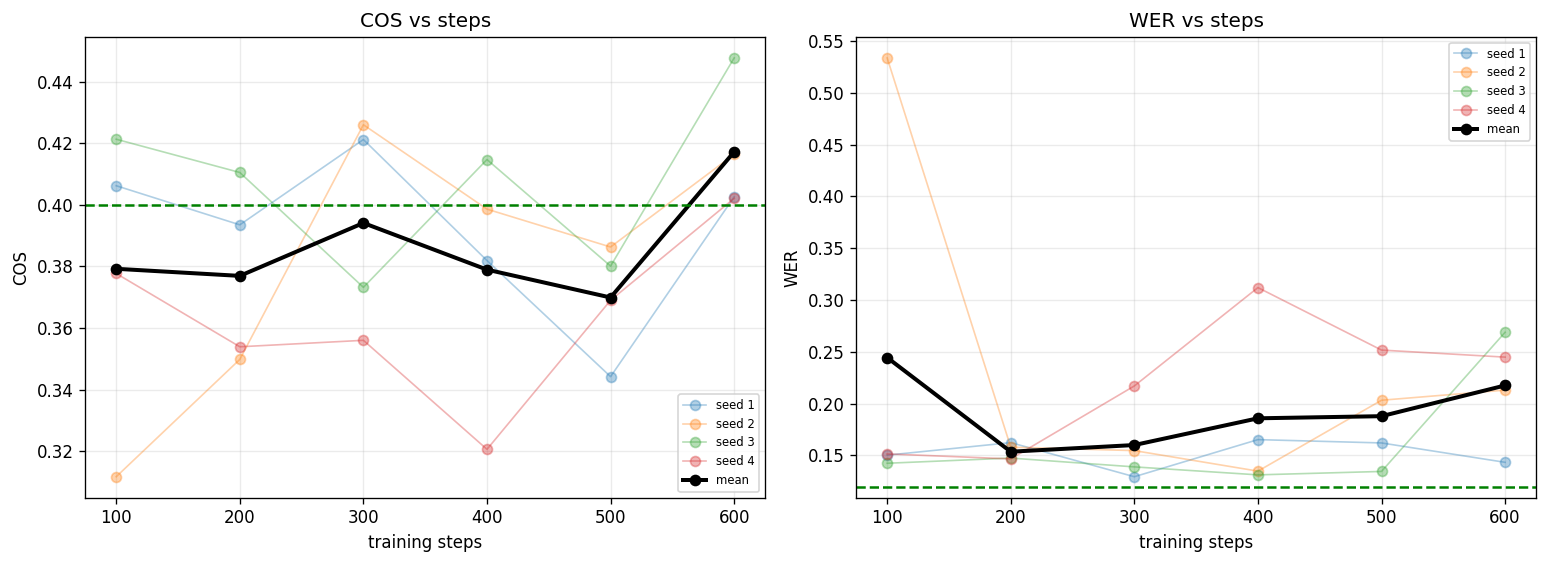

mean COS by step: {100: np.float64(0.379), 200: np.float64(0.377), 300: np.float64(0.394), 400: np.float64(0.379), 500: np.float64(0.37), 600: np.float64(0.417)}
mean WER by step: {100: np.float64(0.244), 200: np.float64(0.154), 300: np.float64(0.16), 400: np.float64(0.186), 500: np.float64(0.188), 600: np.float64(0.218)}


In [2]:
rows=[r for r in csv.DictReader(open("results/SWEEP_RESULTS.csv")) if r["recipe"]=="proj+cosine" and r["step"].isdigit()]
steps=sorted(set(int(r["step"]) for r in rows))
seeds=sorted(set(r["seed"] for r in rows))
def grid(metric):
    M=np.full((len(seeds),len(steps)),np.nan)
    for r in rows:
        si=seeds.index(r["seed"]); ti=steps.index(int(r["step"])); M[si,ti]=float(r[metric])
    return M
COS=grid("cos"); WER=grid("wer")
fig,axs=plt.subplots(1,2,figsize=(13,4.8))
for ax,M,name,tgt in [(axs[0],COS,"COS",0.40),(axs[1],WER,"WER",0.12)]:
    for si,s in enumerate(seeds): ax.plot(steps,M[si],"o-",alpha=.35,lw=1,label=f"seed {s}")
    mean=np.nanmean(M,0); ax.plot(steps,mean,"k-o",lw=2.4,label="mean")
    ax.axhline(tgt,ls="--",c="green"); ax.set_xlabel("training steps"); ax.set_ylabel(name)
    ax.set_title(f"{name} vs steps"); ax.legend(fontsize=7); ax.grid(alpha=.25)
plt.tight_layout(); plt.savefig(ANA/"hp_steps.png"); plt.show()
print("mean COS by step:", {s:round(v,3) for s,v in zip(steps,np.nanmean(COS,0))})
print("mean WER by step:", {s:round(v,3) for s,v in zip(steps,np.nanmean(WER,0))})

## ② Learning rate — {0.005, 0.01, 0.02(기준), 0.04}
300 steps, cosine, warmup 0, seed 1·2.

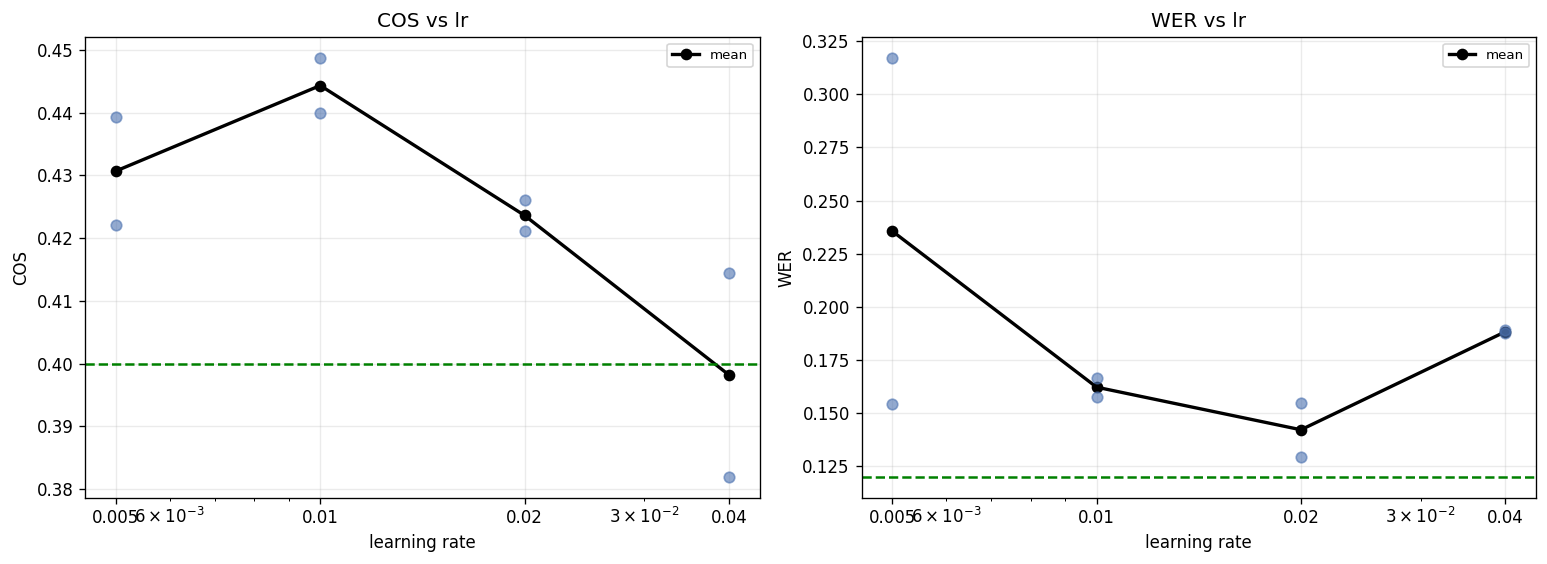

  lr=0.005  COS=0.431±0.009  WER=0.236±0.081  (n=2)
  lr=0.01   COS=0.444±0.004  WER=0.162±0.004  (n=2)
  lr=0.02   COS=0.424±0.002  WER=0.142±0.013  (n=2)
  lr=0.04   COS=0.398±0.016  WER=0.188±0.001  (n=2)


In [3]:
LRS=[("0.005",["lr005_s1","lr005_s2"]),("0.01",["lr01_s1","lr01_s2"]),
     ("0.02",None),("0.04",["lr04_s1","lr04_s2"])]
def agg(tags):
    if tags is None: vals=[BASE.get("1"),BASE.get("2")]
    else: vals=[summ(t) for t in tags]
    vals=[v for v in vals if v]; C=[v[0] for v in vals]; W=[v[1] for v in vals]
    return C,W
xs=[float(l) for l,_ in LRS]
fig,axs=plt.subplots(1,2,figsize=(13,4.8))
for ax,idx,name,tgt in [(axs[0],0,"COS",0.40),(axs[1],1,"WER",0.12)]:
    means=[]
    for (l,tags) in LRS:
        C,W=agg(tags); vals=C if idx==0 else W
        x=float(l); ax.scatter([x]*len(vals),vals,s=40,color="#4C72B0",alpha=.6,zorder=3)
        means.append(np.mean(vals))
    ax.plot(xs,means,"k-o",lw=2,label="mean")
    ax.axhline(tgt,ls="--",c="green"); ax.set_xscale("log"); ax.set_xticks(xs); ax.set_xticklabels([l for l,_ in LRS])
    ax.set_xlabel("learning rate"); ax.set_ylabel(name); ax.set_title(f"{name} vs lr"); ax.grid(alpha=.25); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(ANA/"hp_lr.png"); plt.show()
for l,tags in LRS:
    C,W=agg(tags); print(f"  lr={l:6s} COS={np.mean(C):.3f}±{np.std(C):.3f}  WER={np.mean(W):.3f}±{np.std(W):.3f}  (n={len(C)})")

## ③ Warmup 유무 — cosine, lr0.02, 300 steps
warmup 0 (기준) vs warmup 30 (10%).

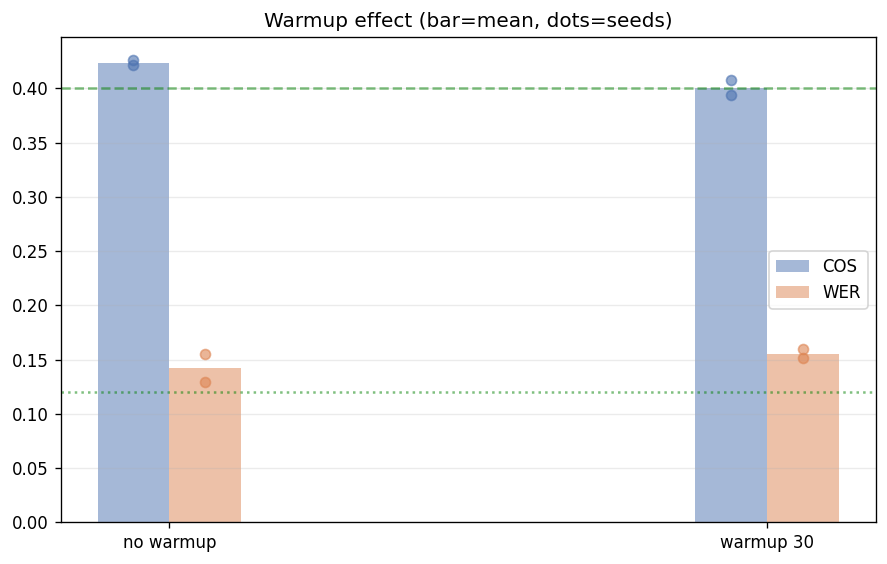

  no warmup  COS=0.424±0.002  WER=0.142±0.013
  warmup 30  COS=0.401±0.007  WER=0.155±0.004


In [4]:
WU=[("no warmup",None),("warmup 30",["wu30_s1","wu30_s2"])]
fig,ax=plt.subplots(figsize=(7.5,4.8))
labels=[l for l,_ in WU]; xpos=np.arange(len(WU))
for j,(idx,name,col) in enumerate([(0,"COS","#4C72B0"),(1,"WER","#DD8452")]):
    means=[];
    for i,(l,tags) in enumerate(WU):
        C,W=agg(tags); vals=C if idx==0 else W; means.append(np.mean(vals))
        ax.scatter([xpos[i]+ (j-0.5)*0.12]*len(vals),vals,s=36,color=col,alpha=.6,zorder=3)
    ax.bar(xpos+(j-0.5)*0.12,means,0.12,color=col,alpha=.5,label=name)
ax.set_xticks(xpos); ax.set_xticklabels(labels); ax.axhline(0.40,ls="--",c="green",alpha=.5)
ax.axhline(0.12,ls=":",c="green",alpha=.5); ax.set_title("Warmup effect (bar=mean, dots=seeds)"); ax.legend(); ax.grid(alpha=.25,axis="y")
plt.tight_layout(); plt.savefig(ANA/"hp_warmup.png"); plt.show()
for l,tags in WU:
    C,W=agg(tags); print(f"  {l:10s} COS={np.mean(C):.3f}±{np.std(C):.3f}  WER={np.mean(W):.3f}±{np.std(W):.3f}")

## ④ LR 스케줄러 — constant vs cosine(기준) vs linear
lr0.02, warmup 0, 300 steps, seed 1·2.

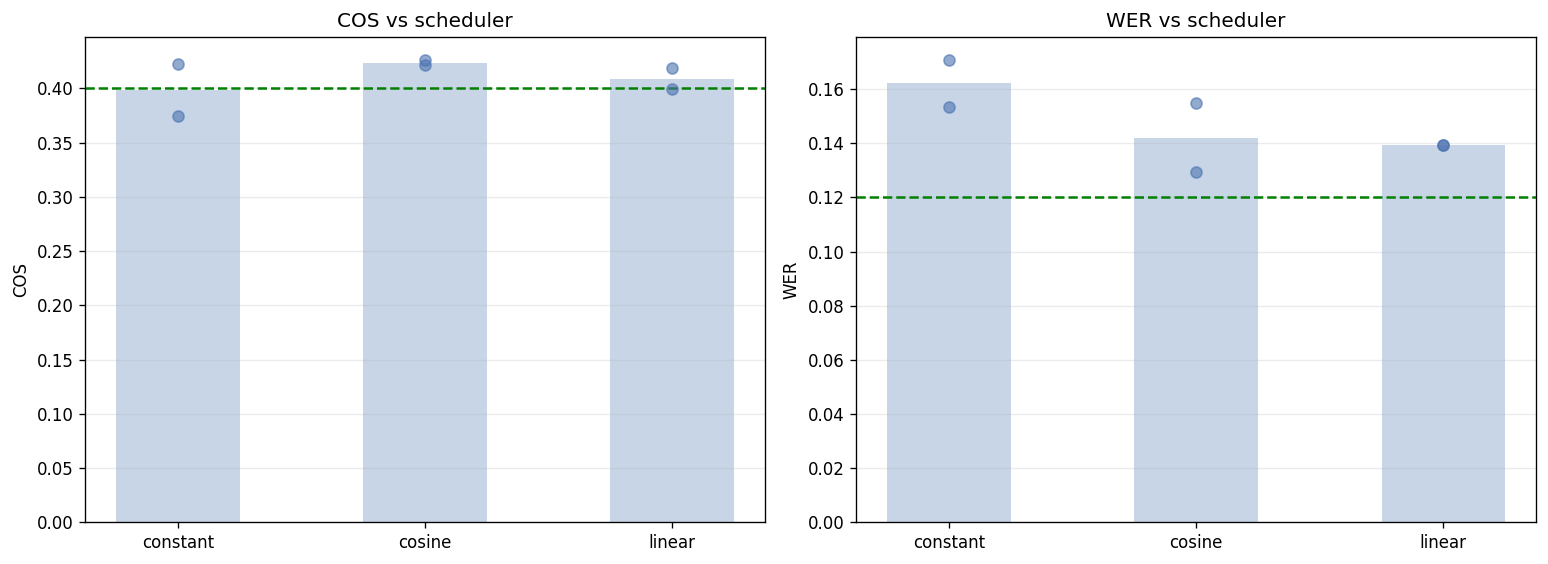

  constant  COS=0.399±0.024  WER=0.162±0.009
  cosine    COS=0.424±0.002  WER=0.142±0.013
  linear    COS=0.409±0.009  WER=0.139±0.000


In [5]:
SCH=[("constant",["const_s1","const_s2"]),("cosine",None),("linear",["lin_s1","lin_s2"])]
xpos=np.arange(len(SCH))
fig,axs=plt.subplots(1,2,figsize=(13,4.8))
for ax,idx,name,tgt in [(axs[0],0,"COS",0.40),(axs[1],1,"WER",0.12)]:
    means=[]
    for i,(l,tags) in enumerate(SCH):
        C,W=agg(tags); vals=C if idx==0 else W; means.append(np.mean(vals))
        ax.scatter([xpos[i]]*len(vals),vals,s=44,color="#4C72B0",alpha=.6,zorder=3)
    ax.bar(xpos,means,0.5,color="#B0C4DE",alpha=.7)
    ax.axhline(tgt,ls="--",c="green"); ax.set_xticks(xpos); ax.set_xticklabels([l for l,_ in SCH])
    ax.set_ylabel(name); ax.set_title(f"{name} vs scheduler"); ax.grid(alpha=.25,axis="y")
plt.tight_layout(); plt.savefig(ANA/"hp_sched.png"); plt.show()
for l,tags in SCH:
    C,W=agg(tags); print(f"  {l:9s} COS={np.mean(C):.3f}±{np.std(C):.3f}  WER={np.mean(W):.3f}±{np.std(W):.3f}")

## 종합 표 + 결론

In [6]:
import csv as _csv
rows_out=[]
def add(axis,cfg,tags):
    C,W=agg(tags); rows_out.append((axis,cfg,np.mean(C),np.std(C),np.mean(W),np.std(W),len(C)))
add("baseline","lr0.02 cosine wu0 300",None)
for l,tags in [("0.005",["lr005_s1","lr005_s2"]),("0.01",["lr01_s1","lr01_s2"]),("0.04",["lr04_s1","lr04_s2"])]: add("lr",f"lr{l}",tags)
add("warmup","warmup30",["wu30_s1","wu30_s2"])
for l,tags in [("constant",["const_s1","const_s2"]),("linear",["lin_s1","lin_s2"])]: add("sched",l,tags)
print(f"{'axis':9s} {'config':22s} {'COS':>14s} {'WER':>14s}  n")
for a,c,cm,cs,wm,ws,n in rows_out:
    print(f"{a:9s} {c:22s} {cm:.3f}±{cs:.3f}   {wm:.3f}±{ws:.3f}   {n}")
with open("results/HP_SWEEP.csv","w") as f:
    w=_csv.writer(f); w.writerow(["axis","config","cos_mean","cos_std","wer_mean","wer_std","n"])
    for r in rows_out: w.writerow([r[0],r[1],f"{r[2]:.4f}",f"{r[3]:.4f}",f"{r[4]:.4f}",f"{r[5]:.4f}",r[6]])
print("\nsaved results/HP_SWEEP.csv")

axis      config                            COS            WER  n
baseline  lr0.02 cosine wu0 300  0.424±0.002   0.142±0.013   2
lr        lr0.005                0.431±0.009   0.236±0.081   2
lr        lr0.01                 0.444±0.004   0.162±0.004   2
lr        lr0.04                 0.398±0.016   0.188±0.001   2
warmup    warmup30               0.401±0.007   0.155±0.004   2
sched     constant               0.399±0.024   0.162±0.009   2
sched     linear                 0.409±0.009   0.139±0.000   2

saved results/HP_SWEEP.csv


### 결론 (실측 수치 기반, 2 seed·표준편차 병기 — 변동 큼)

| 축 | 최적 | 관찰 |
|---|---|---|
| **① step** | **200–300** | WER: step100 undertrain(0.24) → 200–300 최저(~0.15) → 600 과학습(0.22). COS는 0.37–0.42로 노이즈, 뚜렷한 단조성 없음. **더 오래 학습하면 WER이 나빠짐.** |
| **② learning rate** | **0.01–0.02** | lr0.005 COS 0.431/WER **0.236**(너무 낮아 WER 미수렴) · lr0.01 COS **0.444**(최고)/WER 0.162 · lr0.02 COS 0.424/WER **0.142**(최저) · lr0.04 COS 0.398/WER 0.188(과도). **U자형 — 0.01~0.02가 sweet spot.** |
| **③ warmup** | **불필요** | no-warmup 0.424/0.142 vs warmup30 0.401/0.155. **웜업이 COS·WER 모두 소폭 악화** — 300 step·단일 파라미터라 초반을 낭비. |
| **④ scheduler** | **cosine (또는 linear)** | constant 0.399/0.162(최악) < linear 0.409/**0.139** < **cosine 0.424/0.142**. **감쇠 스케줄(cosine/linear)이 constant보다 우수**; cosine이 종합 최선, linear가 WER 약간 낮음. |

**권고 config:** lr **0.01–0.02**, **cosine** 감쇠, **warmup 없이**, **~250–300 step**. (기준 config가 사실상 이 조합.)
**주의:** 이 학습은 시드 변동이 커서(예: 기준 4시드 COS 0.36–0.43) 위 차이 중 표준편차 안에 들어오는 것도 있음 — 큰 경향(lr U자형, decay>constant, 과학습 WER↑, warmup 무익)만 신뢰.

그림: `results/analysis/hp_{steps,lr,warmup,sched}.png` · 수치: `results/HP_SWEEP.csv`.